In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset


In [51]:
data =pd.read_csv('nepal_rental_kathmandu_dataset.csv')
data.head()

,listing_id,title,monthly_rent_npr,area_sqft_approx,road_width_ft,location,ward,municipality,district,property_type,...,living_rooms,kitchens,total_rooms,parking,built_up_sqft,no_of_flats,built_year,description,city,source
0,9541,House for rent,75000.0,1197.88,14.0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",26.0,Kathmandu Metropolis,Kathmandu,house,...,3.0,2.0,8.0,Car 1,2200.0,2.5,2072,Prime location. Posh area.,kathmandu,gharghaderi.com
1,9464,"House on rent: Civil Homes Phase VII, Nagarjun-6",50000.0,1026.75,10.0,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",6.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 3-5,850.0,2.0,2075,A well-maintained house on 2.5 anna land is av...,kathmandu,gharghaderi.com
2,9361,4 BHK Semi Furnished House for Rent at Bhaisepati,119999.0,1540.12,12.0,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",18.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,5.0,Cars 2,1600.0,2.5,2070,4BHK Semi Furninsed house on rent at Bhaisepat...,kathmandu,gharghaderi.com
3,9087,House on Rent at Koteswor for Office or Restau...,250000.0,3935.88,26.0,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",32.0,Kathmandu Metropolis,Kathmandu,house,...,1.0,1.0,9.0,Cars 5-10,3100.0,2.5,2065,NaN,kathmandu,gharghaderi.com
4,9034,Fully-Furnished House on rent at Budhanilkantha,120000.0,1369.00,13.0,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",NaN,Budhanilkantha Kathmandu Metropolis,Kathmandu,house,...,2.0,1.0,NaN,Car 1,NaN,NaN,Select Year,Fully-Furnished House on rent at Budhanilkanth...,kathmandu,gharghaderi.com


In [53]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        156 non-null    int64  
 1   title             156 non-null    str    
 2   monthly_rent_npr  156 non-null    float64
 3   area_sqft_approx  117 non-null    float64
 4   road_width_ft     128 non-null    float64
 5   location          156 non-null    str    
 6   ward              81 non-null     float64
 7   municipality      94 non-null     str    
 8   district          156 non-null    str    
 9   property_type     156 non-null    str    
 10  house_type        118 non-null    str    
 11  direction         156 non-null    str    
 12  bedrooms          148 non-null    float64
 13  bathrooms         153 non-null    float64
 14  living_rooms      89 non-null     float64
 15  kitchens          121 non-null    float64
 16  total_rooms       30 non-null     float64
 17  parking 

In [57]:
data.drop(columns=["listing_id", "source", "district"], inplace=True)

In [59]:
data.head()

,title,monthly_rent_npr,area_sqft_approx,road_width_ft,location,ward,municipality,property_type,house_type,direction,...,bathrooms,living_rooms,kitchens,total_rooms,parking,built_up_sqft,no_of_flats,built_year,description,city
0,House for rent,75000.0,1197.88,14.0,"Samakhusi 26 Kathmandu Metropolis Kathmandu, B...",26.0,Kathmandu Metropolis,house,Furnished,North,...,4.0,3.0,2.0,8.0,Car 1,2200.0,2.5,2072,Prime location. Posh area.,kathmandu
1,"House on rent: Civil Homes Phase VII, Nagarjun-6",50000.0,1026.75,10.0,"Sitapaila 6 Kathmandu Metropolis Kathmandu, Ba...",6.0,Kathmandu Metropolis,house,Residential,Select Direction,...,3.0,1.0,1.0,5.0,Cars 3-5,850.0,2.0,2075,A well-maintained house on 2.5 anna land is av...,kathmandu
2,4 BHK Semi Furnished House for Rent at Bhaisepati,119999.0,1540.12,12.0,"Bhaisepati 18 Kathmandu Metropolis Kathmandu, ...",18.0,Kathmandu Metropolis,house,Residential,South,...,4.0,1.0,1.0,5.0,Cars 2,1600.0,2.5,2070,4BHK Semi Furninsed house on rent at Bhaisepat...,kathmandu
3,House on Rent at Koteswor for Office or Restau...,250000.0,3935.88,26.0,"Koteswor 32 Kathmandu Metropolis Kathmandu, Ba...",32.0,Kathmandu Metropolis,house,Commercial,South,...,5.0,1.0,1.0,9.0,Cars 5-10,3100.0,2.5,2065,NaN,kathmandu
4,Fully-Furnished House on rent at Budhanilkantha,120000.0,1369.00,13.0,"Budhanilkantha Kathmandu Metropolis Kathmandu,...",NaN,Budhanilkantha Kathmandu Metropolis,house,Residential,South,...,3.0,2.0,1.0,NaN,Car 1,NaN,NaN,Select Year,Fully-Furnished House on rent at Budhanilkanth...,kathmandu


In [85]:
for cols in data.columns:
    print(f"{cols:22s} -> {data[cols].nunique()} unique values")

title                  -> 156 unique values
monthly_rent_npr       -> 66 unique values
area_sqft_approx       -> 37 unique values
road_width_ft          -> 18 unique values
location               -> 125 unique values
ward                   -> 20 unique values
municipality           -> 36 unique values
property_type          -> 3 unique values
house_type             -> 8 unique values
direction              -> 11 unique values
bedrooms               -> 12 unique values
bathrooms              -> 10 unique values
living_rooms           -> 10 unique values
kitchens               -> 5 unique values
total_rooms            -> 11 unique values
parking                -> 11 unique values
built_up_sqft          -> 23 unique values
no_of_flats            -> 10 unique values
built_year             -> 19 unique values
description            -> 143 unique values
city                   -> 3 unique values


built_up_sqft       81.4
total_rooms         80.8
ward                48.1
living_rooms        42.9
municipality        39.7
area_sqft_approx    25.0
house_type          24.4
kitchens            22.4
no_of_flats         21.8
road_width_ft       17.9
parking             14.7
description          7.7
bedrooms             5.1
bathrooms            1.9
dtype: float64


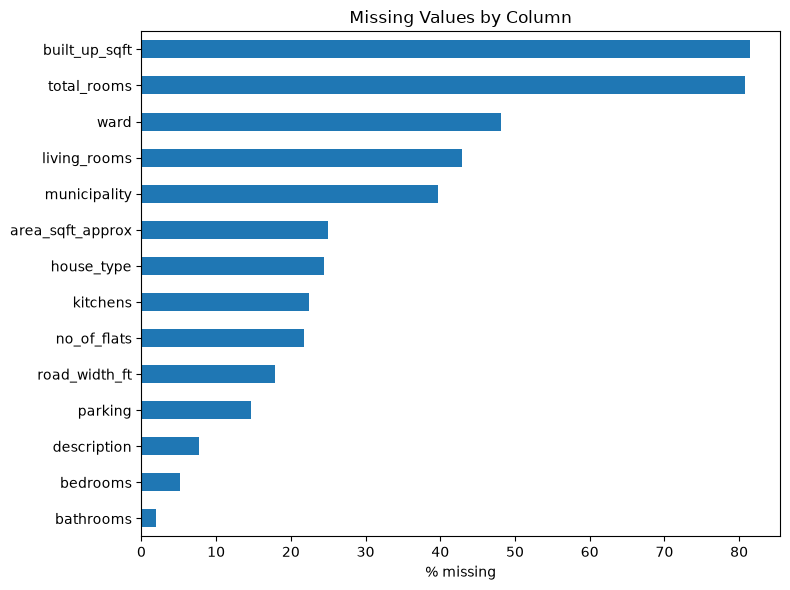

In [81]:
missing = (data.isnull().sum() / len(data) * 100).round(1).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(8, 6))
missing.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missing Values by Column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
